In [2]:
import time
import datetime
from typing import List, Dict, Any, Tuple, Optional, Union
import numpy as np
import scipy as sc
import torch
from torch import autograd
from pulp import (
    LpProblem, LpVariable, LpMinimize, LpMaximize, 
    LpStatus, LpBinary, lpSum, GUROBI_CMD
)
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from src.custom_fastkan import FastKAN, FastKANLayer
import src.kan_verification_grapher as kan_verification_grapher

# Training (on ODE Duffing Oscillator)

Steps: 5
Dataset shape: torch.Size([250, 4])
Train dataset shape: torch.Size([225, 4]), Test dataset shape: torch.Size([25, 4])
Starting training...


/var/folders/d_/pj_vvqcj1lj9fqtdrzb8hgjm0000gn/T/ipykernel_8166/1714010783.py:80: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3729.)
  t_eval_set = t_eval.T.repeat(s_size).view(-1, 1).to(device)


Iteration 0, Loss: 0.01591334119439125
Iteration 1, Loss: 0.004197398666292429
Iteration 2, Loss: 0.001791246235370636
Iteration 3, Loss: 0.0009528062073513865
Iteration 4, Loss: 0.0006212409352883697

Test set predictions:


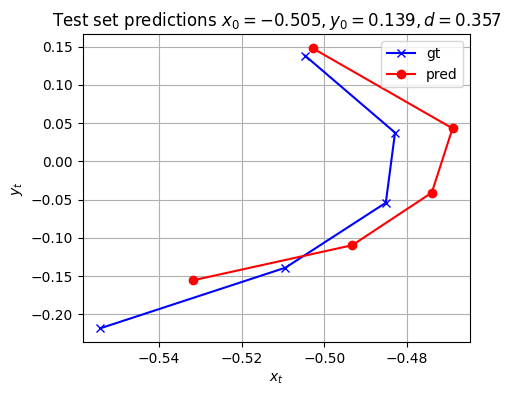

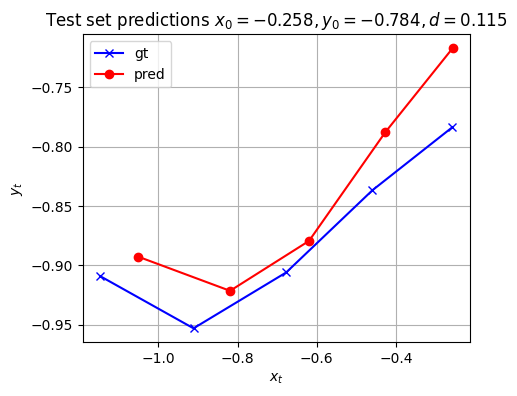


Train set predictions:


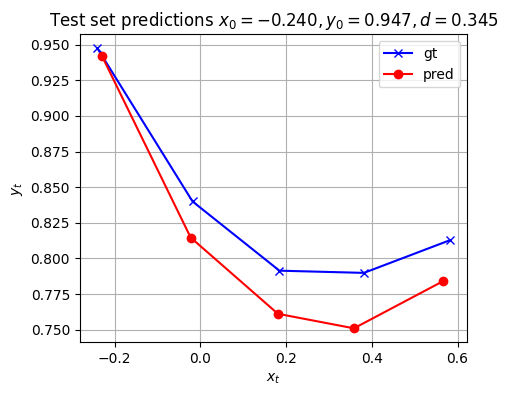

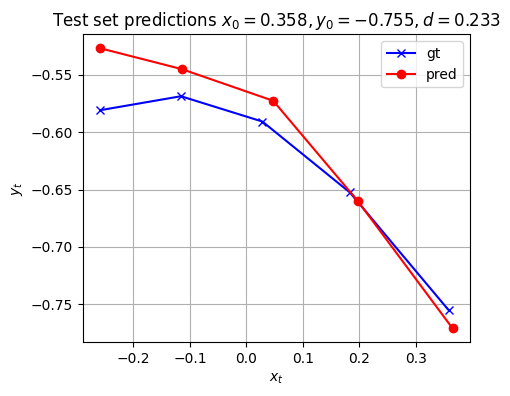


Computing error metrics on test set:
Overall R2-Score (test dataset): 0.9870883226394653

Computing error metrics on train set:
Overall R2-Score (train dataset): 0.9990546703338623


In [2]:
class LBFGS(torch.optim.LBFGS):
    def __init__(self, params, lr=1, history_size=10, tolerance_grad=1e-32, tolerance_change=1e-32, tolerance_ys=1e-32):
        super().__init__(params, lr=lr, history_size=history_size, tolerance_grad=tolerance_grad, 
                         tolerance_change=tolerance_change)
        self.tolerance_ys = tolerance_ys

def compute_jacobian(model, x):
    def ret_sum(x):
        return model(x)
    jacb = autograd.functional.jacobian(ret_sum, x, create_graph=True)
    jacb = jacb[:, :, :, 0]
    jacb = jacb.sum(dim=-1).unsqueeze(-1) 
    return jacb

def compute_ode(y_pred, x):
    def ode(init_cond, d):
        return init_cond[:, 1], init_cond[:, 0] - init_cond[:, 0]**3 - d*init_cond[:, 1]
    grad = ode(y_pred, x[:, 3])
    grad = torch.tensor([[dxdt, dydt] for dxdt, dydt in zip(grad[0], grad[1])], device=device).unsqueeze(-1) 
    return grad

def compute_forward_integrals(dataset, duration, t_eval):
    def system_cont(t, x, d):
        dxdt = [x[1], x[0] - x[0]**3 - d*x[1]]
        return dxdt 
    sol_set = []
    for init_cond in dataset.detach().cpu().numpy():
        t, x0, y0, d = init_cond[0], init_cond[1], init_cond[2], init_cond[3]
        sol = sc.integrate.solve_ivp(system_cont, [0, duration], (x0, y0), args=(d,), t_eval=t_eval)
        sol_set.extend(np.array(sol.y.T))
    sol_set = torch.tensor(np.array(sol_set), dtype=torch.float32, device=device)
    return sol_set

# Loss Function
def ode_residuals(model, coords, steps, duration, t_eval, alpha=1.0, beta=1.0, gamma=1.0):
    coords = coords.clone().detach().requires_grad_(True)
    y_pred = model(coords) 
    y_gt = compute_forward_integrals(coords[::steps], duration, t_eval.cpu().numpy())
    kan_autograd = compute_jacobian(model, coords)
    kan_ode_grad = compute_ode(y_pred, coords)
    init_kan_grad = y_pred[::steps]
    init_ode_grad = coords[::steps][:, 1:3]
    dyn_loss = torch.mean((kan_autograd - kan_ode_grad)**2)
    integral_loss = torch.mean((y_pred - y_gt)**2)
    init_loss = torch.mean((init_kan_grad - init_ode_grad)**2)
    batch_loss = alpha*dyn_loss + beta*integral_loss + beta*init_loss
    return batch_loss

def train(model):
    optimizer = LBFGS(model.parameters(), lr=1, history_size=10, tolerance_grad=1e-32, 
                     tolerance_change=1e-32, tolerance_ys=1e-32)
    iter_ = 5
    for i in range(iter_):
        def closure():
            optimizer.zero_grad()
            loss = ode_residuals(model, dataset, steps, duration, t_eval, alpha=0.2, beta=0.6, gamma=0.2)
            loss.backward()
            return loss
        optimizer.step(closure)
        if i % 1 == 0:
            current_loss = closure().item()
            print(f"Iteration {i}, Loss: {current_loss}")

# Create the dataset for the model
device = "cpu"
s_size = 50
x_sample = np.random.uniform(-1, 1, size=s_size)
y_sample = np.random.uniform(-1, 1, size=s_size)
d_sample = np.random.uniform(0.1, 0.5, size=s_size)
x_sample = torch.tensor(x_sample, dtype=torch.float32, device=device)
y_sample = torch.tensor(y_sample, dtype=torch.float32, device=device)
d_sample = torch.tensor(d_sample, dtype=torch.float32, device=device)
duration = 1
time_interval = 0.2
steps = int(duration / time_interval)
print(f"Steps: {steps}")
t_eval = torch.linspace(0, duration, steps=steps)
dataset = torch.stack([x_sample, y_sample, d_sample], dim=1).to(device)
dataset = dataset.repeat_interleave(steps, dim=0)
t_eval_set = t_eval.T.repeat(s_size).view(-1, 1).to(device)
dataset = torch.cat([t_eval_set, dataset], dim=1)
dataset.requires_grad = True
print(f"Dataset shape: {dataset.shape}")
test_size = 5
test_dataset = dataset[(s_size-test_size)*steps:]
dataset = dataset[:(s_size-test_size)*steps]
print(f"Train dataset shape: {dataset.shape}, Test dataset shape: {test_dataset.shape}")

# Base Update and Layernorm must be set to false for verificaton 
kan_duffing = FastKAN(layers_hidden=[4, 15, 2], grid_min=-2., grid_max=2., num_grids=15, use_base_update = False, use_layernorm=False)
print("Starting training...")

train(kan_duffing)
print("\nTest set predictions:")
kan_verification_grapher.graph_ode_results(test_dataset, kan_duffing, steps, t_eval, duration)
print("\nTrain set predictions:")
kan_verification_grapher.graph_ode_results(dataset, kan_duffing, steps, t_eval, duration)

print("\nComputing error metrics on test set:")
sol_map = []
for init_conds in test_dataset[::steps].detach().cpu().numpy():
    sol, _ = kan_verification_grapher.system_eq_dis(init_conds[1:], t_eval.numpy(), duration)
    sol_map.extend(sol)
pred = kan_duffing(test_dataset).detach().numpy()
res_score = r2_score(sol_map, pred)
print(f"Overall R2-Score (test dataset): {res_score}")
print("\nComputing error metrics on train set:")
sol_map = []
for init_conds in dataset[::steps].detach().cpu().numpy():
    sol, _ = kan_verification_grapher.system_eq_dis(init_conds[1:], t_eval.numpy(), duration)
    sol_map.extend(sol)
pred = kan_duffing(dataset).detach().numpy()
res_score = r2_score(sol_map, pred)
print(f"Overall R2-Score (train dataset): {res_score}")

# Fitting Linear Segments (Vanilla)

![image.png](images/DP_bspline.png)

Fitting Layer 0 (4 -> 15)
Fitting Layer 1 (15 -> 2)
Generated data for 90 connections.


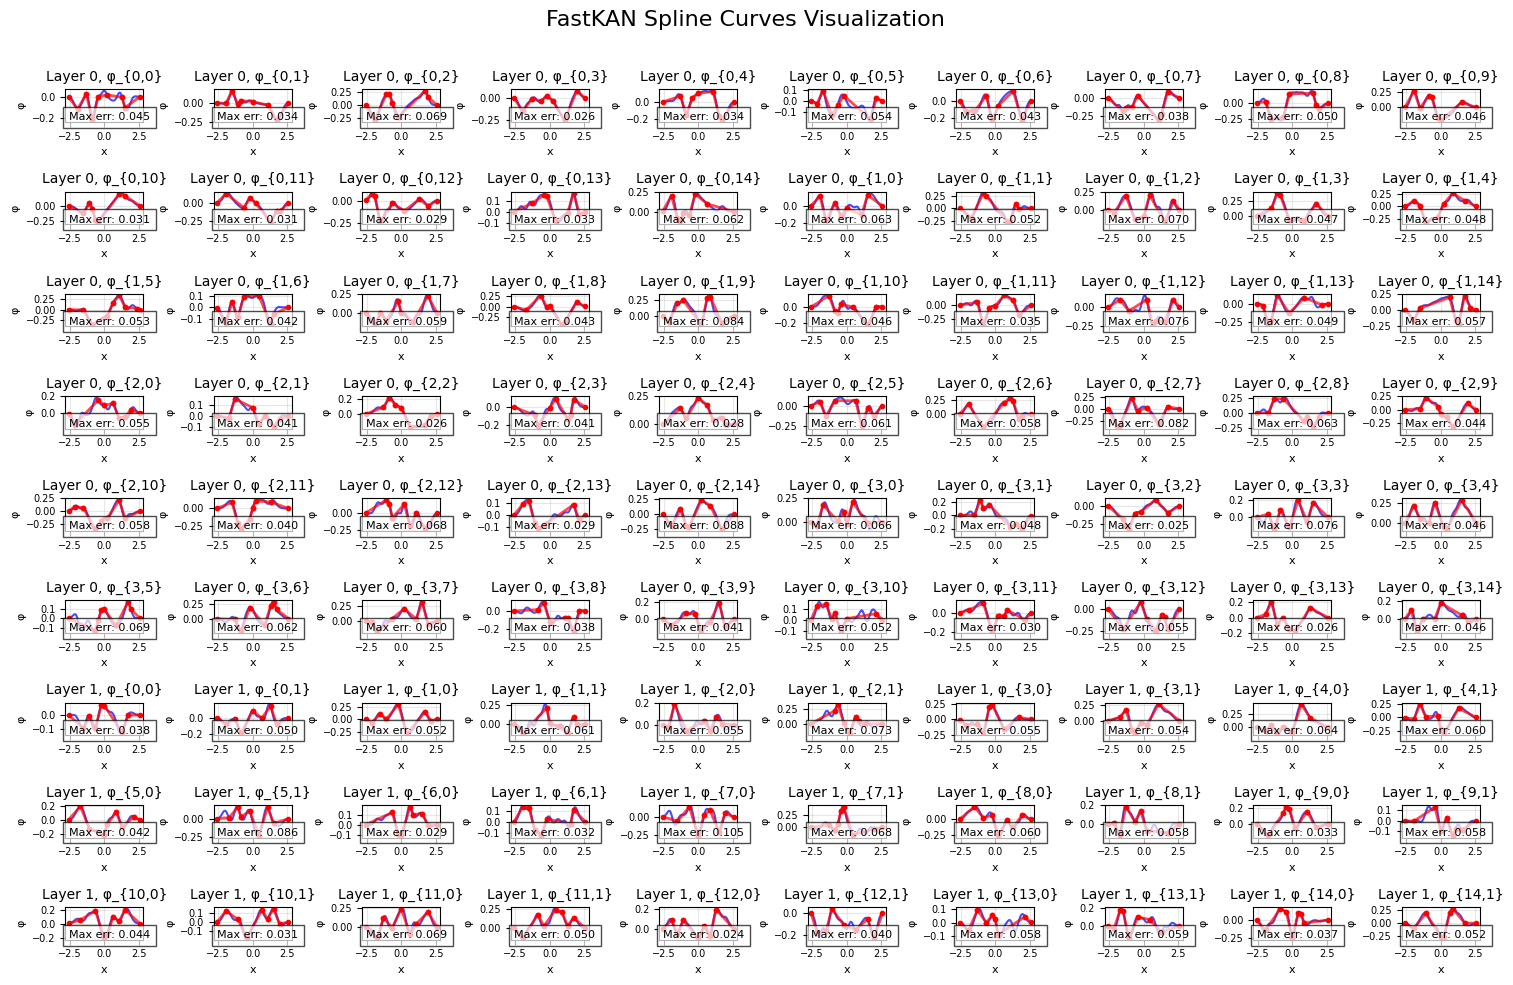

In [8]:
def fit_line_through_points(x1, y1, x2, y2):
    slope = (y2 - y1) / (x2 - x1)
    intercept = y1 - slope * x1
    return slope, intercept

def find_bspline_segments_given_max_segments(layer, input_index, output_index, max_segments, min_x, max_x):
    """
    Used in both the vanilla fitting method and DP method.
    Given a single B-Spline in the network and a budget of segments,
    use DP to fit them optimally (minimizing the max error).
    """
    # Sample points from the spline (within defined x range)
    n_samples = 25
    x_points = np.linspace(min_x, max_x, n_samples)
    x_tensor, y_tensor = layer.plot_curve(input_index, output_index, num_pts=n_samples)
    x_np = x_tensor.detach().cpu().numpy()
    y_np = y_tensor.detach().cpu().numpy()
    mask = (x_np >= min_x) & (x_np <= max_x)
    x_points = x_np[mask]
    y_points = y_np[mask]
    n = len(x_points)
    
    # Precompute errors for all possible segments
    errors = np.full((n, n), np.inf)
    for start_idx in range(n-1):
        max_len = min(n - start_idx, int(np.round((max_x - min_x) / ((max_x - min_x) / n))))
        x_start = x_points[start_idx]
        y_start = y_points[start_idx]
        for end_idx in range(start_idx + 1, start_idx + max_len):
            if end_idx >= n:
                break
            x_end = x_points[end_idx]
            y_end = y_points[end_idx]
            if abs(x_end - x_start) <= 1e-10:
                continue
            slope = (y_end - y_start) / (x_end - x_start)
            intercept = y_start - slope * x_start
            segment_x = x_points[start_idx:end_idx+1]
            segment_y = y_points[start_idx:end_idx+1]
            predicted_y = slope * segment_x + intercept
            segment_error = np.max(np.abs(predicted_y - segment_y))
            errors[start_idx, end_idx] = segment_error
    
    # Dynamic programming to find optimal segmentation
    dp = np.full((max_segments, n), np.inf)
    back = np.zeros((max_segments, n), dtype=int)
    for j in range(1, n):  # Base Case: one segment from start to j
        dp[0, j] = errors[0, j] 
    # TODO: add in recurrence relation
    for i in range(1, max_segments):
        for j in range(i+1, n):
            for k in range(i, j):
                if dp[i-1, k] == np.inf:
                    continue
                if errors[k, j] == np.inf:
                    continue
                curr_error = max(dp[i-1, k], errors[k, j])
                if curr_error < dp[i, j]:
                    dp[i, j] = curr_error
                    back[i, j] = k
    
    # Reconstruct the segments
    segments = []
    curr_seg = n - 1
    if dp[max_segments-1, curr_seg] == np.inf:
        return [], np.inf
    for i in range(max_segments-1, -1, -1):
        if i > 0:
            prev_seg = back[i, curr_seg]
        else:
            prev_seg = 0
        x1, y1 = x_points[prev_seg], y_points[prev_seg]
        x2, y2 = x_points[curr_seg], y_points[curr_seg]
        slope, intercept = fit_line_through_points(x1, y1, x2, y2)
        segments.insert(0, (x1, x2, slope, intercept))
        curr_seg = prev_seg
        if curr_seg <= 0:
            break
        
    return segments, dp[max_segments-1, n-1]

def fit_kan_vanilla(kan_model, segments_per_curve, min_x, max_x):
    """
    Our baseline fitting method for the KAN model.
    We assign the same number of segments to each curve for approximation.
    Then, use Gurobi to solve for output bounds and track time to get a target to beat.
    """
    all_segments = []
    for layer_idx, layer in enumerate(kan_model.layers):
        layer.cpu()
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        print(f"Fitting Layer {layer_idx} ({input_dim} -> {output_dim})")
        for input_index in range(input_dim):
            for output_index in range(output_dim):
                segments, max_error = find_bspline_segments_given_max_segments(layer, input_index, output_index, segments_per_curve, min_x, max_x)
                all_segments.append({
                    'layer_idx': layer_idx,
                    'input_idx': input_index,
                    'output_idx': output_index,
                    'segments': segments,
                    'max_error': max_error
                })
    print(f"Generated data for {len(all_segments)} connections.")
    return all_segments


all_segments = fit_kan_vanilla(
    kan_duffing,
    min_x=-5.0,
    max_x=5.0,
    segments_per_curve=8
)

fig = kan_verification_grapher.plot_kan(
    kan_duffing,
    all_segments,
    figsize=(15, 10),
    min_x=-5.0,
    max_x=5.0,
    num_pts=100,
)
plt.show()

# Fitting Linear Segments (Lipschitz)

### Generate DP Tables for Every B-Spline

![image.png](images/DP_kan.png)

In [4]:
def calculate_bspline_lipschitz_constant(layer: 'FastKANLayer', input_idx: int, output_idx: int, num_pts: int = 1000, min_x: float = None, max_x: float = None) -> float:
    if min_x is None:
        min_x = layer.rbf.grid_min
    if max_x is None:
        max_x = layer.rbf.grid_max
    x_tensor, y_tensor = layer.plot_curve(input_idx, output_idx, num_pts=num_pts)
    x_np = x_tensor.detach().cpu().numpy()
    y_np = y_tensor.detach().cpu().numpy()
    mask = (x_np >= min_x) & (x_np <= max_x)
    x_np = x_np[mask]
    y_np = y_np[mask]

    dx = np.diff(x_np)
    dy = np.diff(y_np)
    nonzero_dx = dx != 0
    slopes = np.zeros_like(dx)
    slopes[nonzero_dx] = dy[nonzero_dx] / dx[nonzero_dx]
    lipschitz_constant = np.max(np.abs(slopes))
    return lipschitz_constant

def compute_dp_tables_lipschitz(kan_model, min_x=-5.0, max_x=5.0, max_segments=15):
    """
    Compute the error tables, segments tables, and Lipschitz constants for all B-splines in the KAN model.
    This is used for the DP method later.
    """
    error_tables = {}
    segments_tables = {}
    lipschitz_constants = {}
    
    # Iterate through all layers
    for layer_idx, layer in enumerate(kan_model.layers):
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        print(f"Analyzing Layer {layer_idx}: {input_dim} inputs -> {output_dim} outputs")
        # Iterate through all B-splines in this layer
        for input_idx in range(input_dim):
            for output_idx in range(output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                layer = kan_model.layers[layer_idx]
                error_table = {}
                segments_table = {}
                for num_segments in range(1, max_segments + 1):
                    segments, error = find_bspline_segments_given_max_segments(layer, input_idx, output_idx, num_segments, min_x, max_x)
                    error_table[num_segments] = error
                    segments_table[num_segments] = segments
                lipschitz_constant = calculate_bspline_lipschitz_constant(layer=layer, input_idx=input_idx, output_idx=output_idx)
                error_tables[spline_key] = error_table
                segments_tables[spline_key] = segments_table
                lipschitz_constants[spline_key] = lipschitz_constant
    
    return error_tables, segments_tables, lipschitz_constants

### Weight DP Table Using Lipschitz Constants

![image.png](images/lipschitz.jpg)

Analyzing Layer 0: 4 inputs -> 15 outputs
Analyzing Layer 1: 15 inputs -> 2 outputs
Weighing Layer 0: 4 inputs -> 15 outputs
Weighing Layer 1: 15 inputs -> 2 outputs
  Achieved error: 0.09992923196579184
  Total segments allocated: 424

Dynamic Programming Table (Error values):
--------------------------------------------------------------------------------
Spline \ Segments |     0 |    20 |    40 |    60 |    80 |   100 |   120 |   140 |   160 |   180 |   200 |   220 |   240 |   260 |   280 |   300 |   320 |   340 |   360 |   380 |   400 |   420
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
  0 | 0.000 | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf   | inf  
  1 | inf   | 0.002 | inf   | inf   | inf   | inf   | inf   | inf   | in

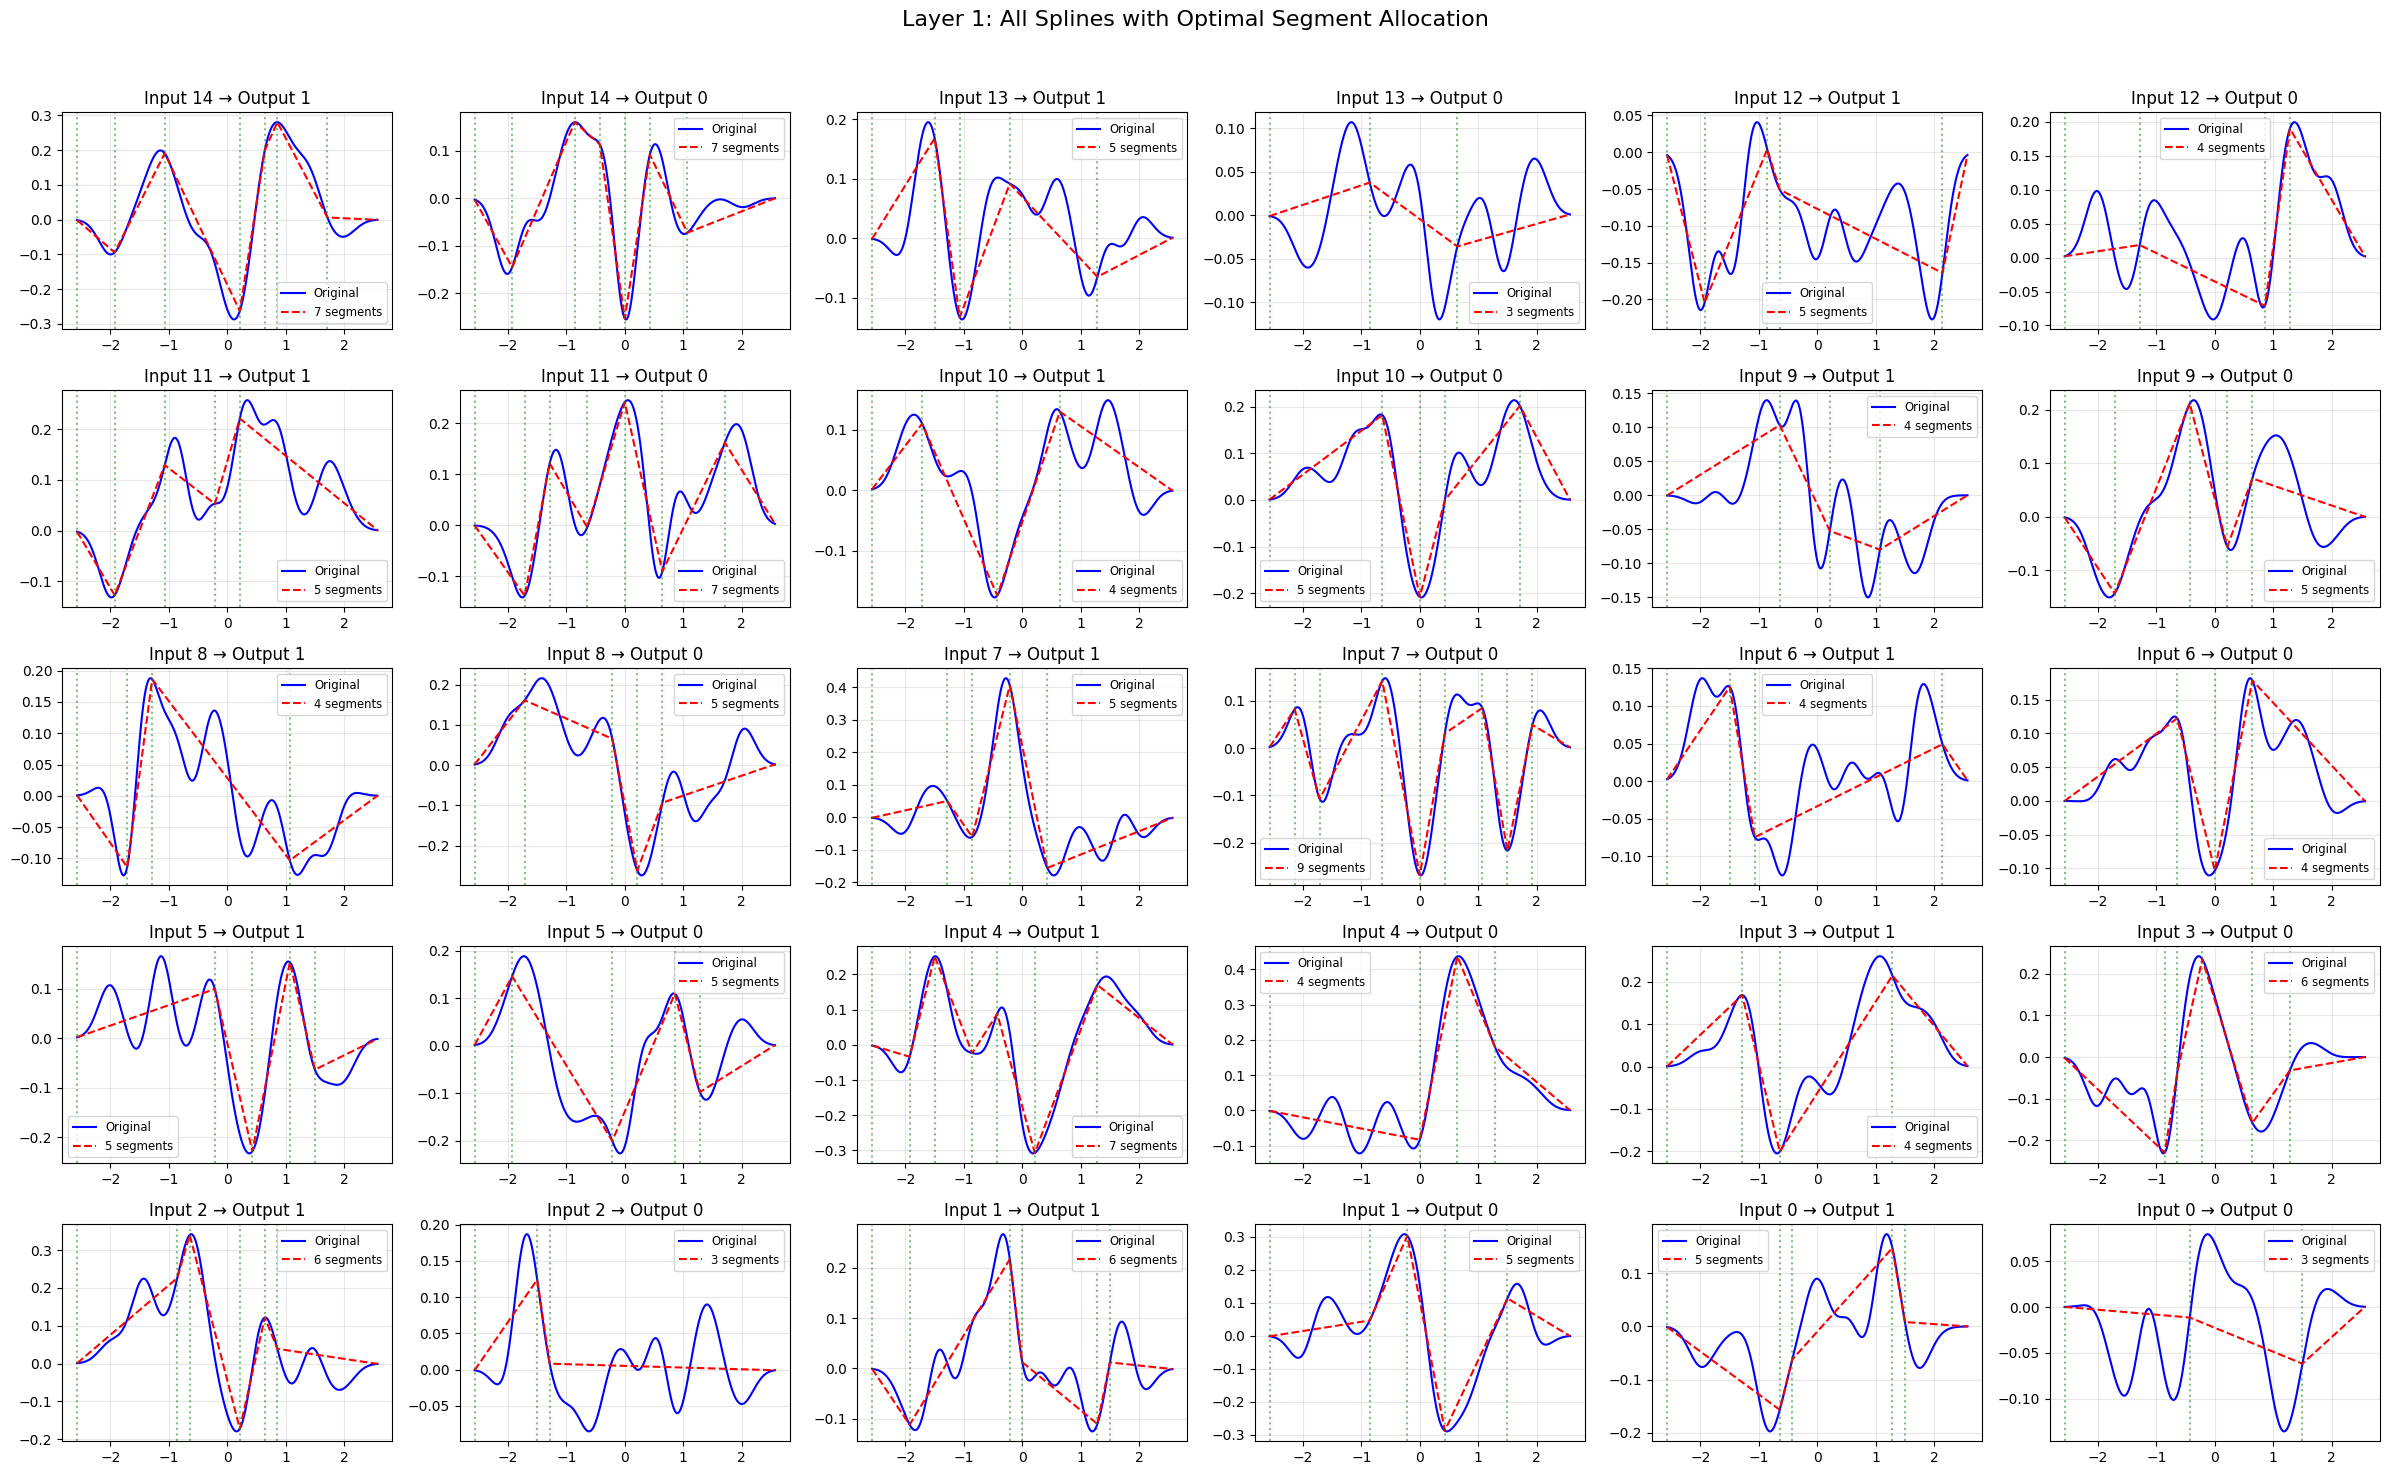

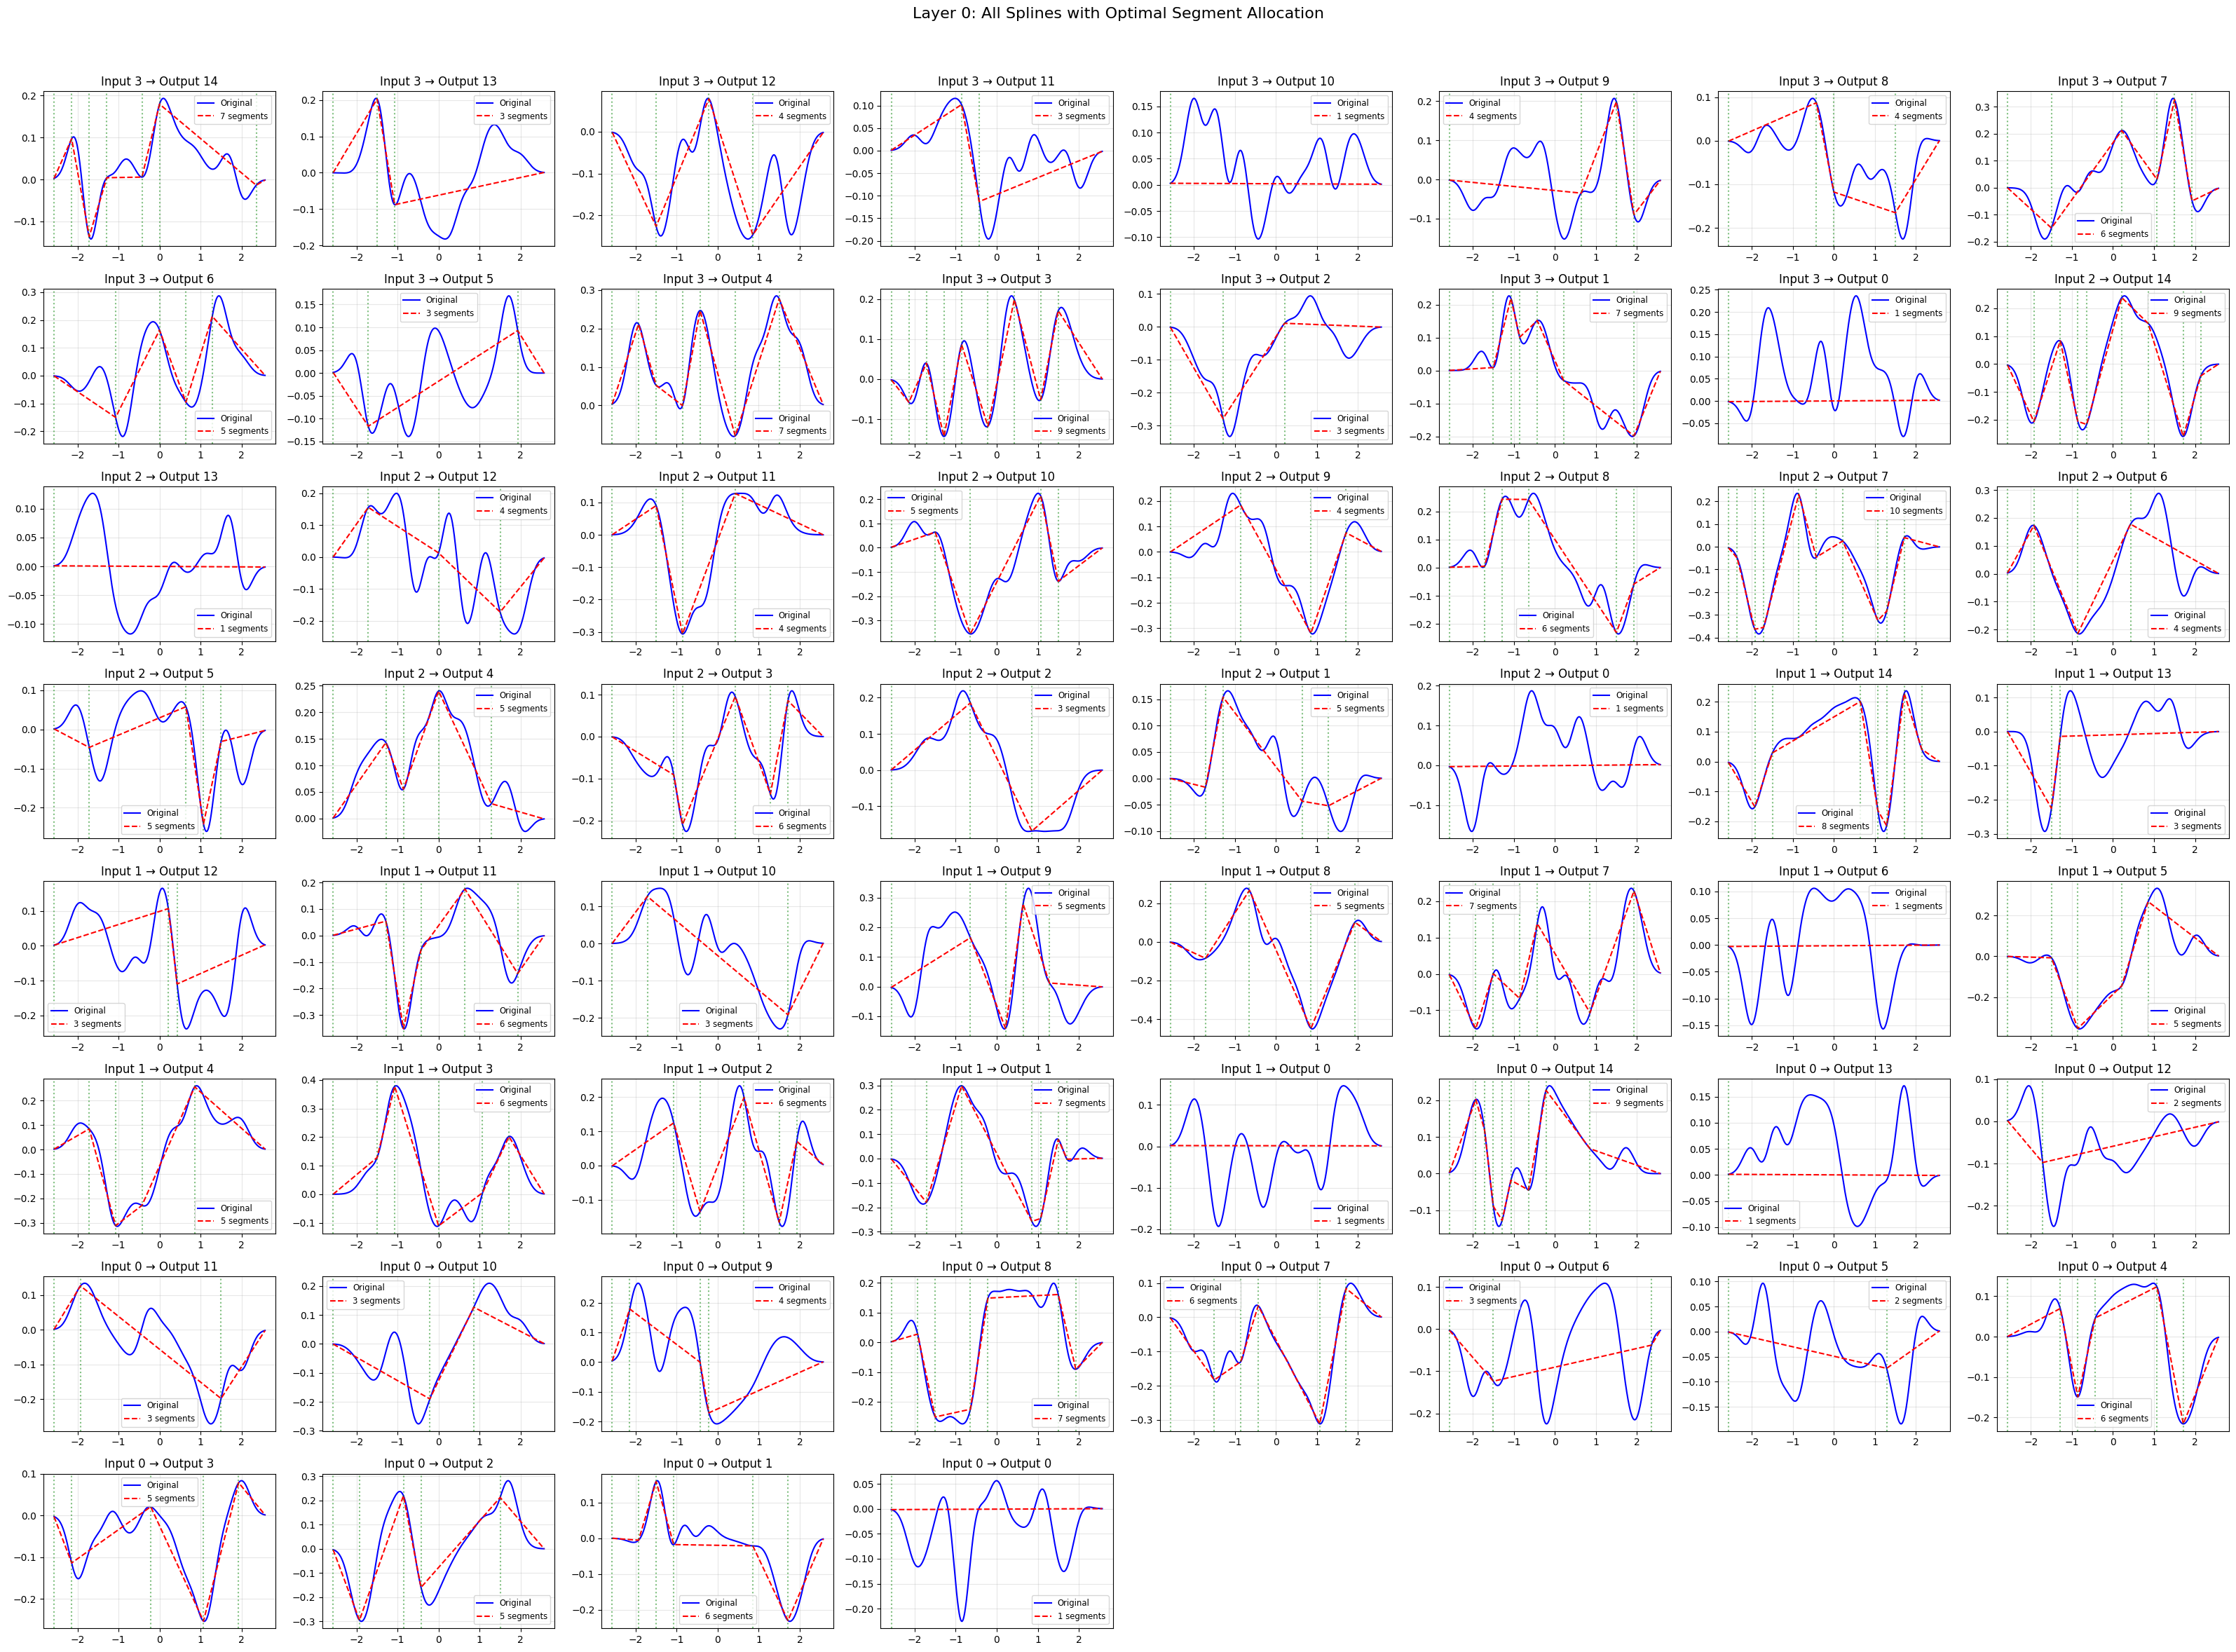

In [10]:
def get_all_downstream_splines(kan_model, layer_idx, output_idx, visited=None):
    """
    Find all downstream splines in the KAN model starting from a given spline (at position layer_idx, output_idx).
    This is used to compute the Lipschitz constant for a certain spline.
    """
    if visited is None:
        visited = set()
    # Base Case: last layer has no downstream splines
    if layer_idx >= len(kan_model.layers) - 1:
        return set()
    # The output of current spline becomes an input in the next layer
    next_input_idx = output_idx
    next_layer_idx = layer_idx + 1
    next_layer = kan_model.layers[next_layer_idx]
    downstream_splines = set()
    for next_output_idx in range(next_layer.output_dim):
        next_spline = (next_layer_idx, next_input_idx, next_output_idx)
        if next_spline not in visited:
            visited.add(next_spline)
            downstream_splines.add(next_spline)
            further_downstream = get_all_downstream_splines(kan_model, next_layer_idx, next_output_idx, visited)
            downstream_splines.update(further_downstream)
    return downstream_splines

def weight_dp_tables_lipschitz(kan_model, min_x=-5.0, max_x=5.0, max_segments=15):
    """
    Weight the error tables for every B-Spline by the product of Lipschitz constants of all downstream splines.
    (ie. weight the error tables by their overall effect on the network output bound)
    """
    error_tables, segments_tables, lipschitz_constants = compute_dp_tables_lipschitz(kan_model, min_x, max_x, max_segments)
    weighted_error_tables = {}
    # Iterate through all splines in the network
    for layer_idx, layer in enumerate(kan_model.layers):
        input_dim = layer.input_dim
        output_dim = layer.output_dim
        print(f"Weighing Layer {layer_idx}: {input_dim} inputs -> {output_dim} outputs")
        for input_idx in range(input_dim):
            for output_idx in range(output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                downstream_splines = get_all_downstream_splines(kan_model, layer_idx, output_idx)
                # Weight the error table by computing the product of Lipschitz constants of all downstream splines
                lipschitz_product = 1.0
                for downstream_spline in downstream_splines:
                    if downstream_spline in lipschitz_constants:
                        lipschitz_product *= lipschitz_constants[downstream_spline]
                weighted_table = {}
                for num_segments, error in error_tables[spline_key].items():
                    weighted_table[num_segments] = error * lipschitz_product
                weighted_error_tables[spline_key] = weighted_table
    return weighted_error_tables, segments_tables, lipschitz_constants

def fit_kan_optimally_lipschitz(weighted_error_tables, segments_tables, max_error, max_segments=50):
    """
    Use DP to find the optimal allocation of segments to splines in the KAN model.
    (Use the weighted error tables computed above).
    """
    used_backup_allocation = False
    all_splines = list(weighted_error_tables.keys())
    num_splines = len(all_splines)
    max_total_segments = num_splines * max_segments
    
    # Initialization: dp[i][j] = minimum error achievable when allocating j total segments to the first i splines
    dp = np.full((num_splines + 1, max_total_segments + 1), float('inf'))
    dp[0, 0] = 0  # Base case: 0 error when allocating 0 segments to 0 splines
    backtrack = np.zeros((num_splines + 1, max_total_segments + 1), dtype=int)
    for i in range(1, num_splines + 1):
        spline_key = all_splines[i-1]
        for j in range(max_total_segments + 1):
            # Try different allocations for the current spline (updating allocation if we find a better error)
            for segs in range(min(j + 1, max_segments + 1)):
                if segs not in weighted_error_tables[spline_key]:
                    continue
                spline_error = weighted_error_tables[spline_key][segs]
                prev_error = dp[i-1, j-segs]
                if prev_error != float('inf') and max(prev_error, spline_error) < dp[i, j]:
                    dp[i, j] = max(prev_error, spline_error)
                    backtrack[i, j] = segs
    
    # Backtrack: Find the min total segments to achieve error <= max_error
    optimal_total_segments = None
    achieved_error = float('inf')
    for j in range(max_total_segments + 1):
        if dp[num_splines, j] <= max_error:
            optimal_total_segments = j
            achieved_error = dp[num_splines, j]
            break
    if optimal_total_segments is None:
        min_error_idx = np.argmin(dp[num_splines, :])
        optimal_total_segments = min_error_idx
        achieved_error = dp[num_splines, min_error_idx]
        print(f"Could not find allocation satisfying the max error constraint ({max_error}).")
        print(f"Returning best allocation with error: {achieved_error}")
        used_backup_allocation = True
    optimal_allocation = {}
    actual_segments = {}
    remaining_segments = optimal_total_segments
    for i in range(num_splines, 0, -1):
        spline_key = all_splines[i-1]
        # Get the segment allocation for this spline and store the coordinates of its linear segments
        segs_for_spline = int(backtrack[i, remaining_segments])
        optimal_allocation[spline_key] = segs_for_spline
        actual_segments[spline_key] = segments_tables[spline_key].get(segs_for_spline, [])
        remaining_segments -= segs_for_spline
    total_segments = sum(optimal_allocation.values())
    print(f"  Achieved error: {achieved_error}")
    print(f"  Total segments allocated: {total_segments}")

    return optimal_allocation, actual_segments, total_segments, achieved_error, dp, used_backup_allocation

weighted_error_tables, segments_tables, lipschitz_constants = weight_dp_tables_lipschitz(
    kan_duffing, min_x=-5.0, max_x=5.0, max_segments=30
)
optimal_allocation, actual_segments, total_segments, achieved_error, dp_table, _ = fit_kan_optimally_lipschitz(
    weighted_error_tables, 
    segments_tables,
    max_error=0.1
)
kan_verification_grapher.print_dp_table(dp_table, len(optimal_allocation), total_segments)
figures = kan_verification_grapher.visualize_all_splines(kan_duffing, optimal_allocation, actual_segments)

# MILP Verification

![image.png](images/MILP.jpg)

### Defining MILP Solver

In [6]:
class SplineApproximation:
    """
    Class to represent a spline approximation for a single connection in the KAN model.
    """
    def __init__(self, segments: List[Tuple[float, float, float, float]], max_error: float):
        self.segments = sorted(segments, key=lambda s: s[0]) if segments else []
        self.original_max_error = max_error
        self.max_error_mip = max_error if np.isfinite(max_error) else 1e7 # For MIP solver stability

    def is_valid(self):
        return bool(self.segments) and np.isfinite(self.original_max_error)


def prep_segments_data(kan_segments_data: List[dict], input_dim: int, hidden_dim: int, output_dim: int):
    """
    Seperate the segments data by layer to make verification easier.
    """
    layer0_approximations = [[None for _ in range(hidden_dim)] for _ in range(input_dim)]
    layer1_approximations = [[None for _ in range(output_dim)] for _ in range(hidden_dim)]
    processed_indices_l0 = set()
    processed_indices_l1 = set()
    segments_layer0 = [s for s in kan_segments_data if s['layer_idx'] == 0]
    segments_layer1 = [s for s in kan_segments_data if s['layer_idx'] == 1]

    for seg_data in segments_layer0:
        i = seg_data['input_idx']
        h = seg_data['output_idx']
        approx = SplineApproximation(seg_data['segments'], seg_data['max_error'])
        layer0_approximations[i][h] = approx
        processed_indices_l0.add((i, h))

    for seg_data in segments_layer1:
        h = seg_data['input_idx']
        o = seg_data['output_idx']
        approx = SplineApproximation(seg_data['segments'], seg_data['max_error'])
        layer1_approximations[h][o] = approx
        processed_indices_l1.add((h, o))

    return layer0_approximations, layer1_approximations

def MIP_interval_analysis(
    layer0_approximations: List[List[Optional[SplineApproximation]]],
    layer1_approximations: List[List[Optional[SplineApproximation]]],
    x_min_vec: Union[List[float], np.ndarray],
    x_max_vec: Union[List[float], np.ndarray],
    M: float = 1e4,
):
    """
    Set up the MIP problem for the KAN model using the provided layer approximations and input bounds.
    Returns the results of the optimization for each output dimension.
    """
    if (not layer0_approximations or not layer0_approximations[0]) or (not layer1_approximations or not layer1_approximations[0]):
        print("Error: layer_approximations is empty or invalid.")
        return []
    input_dim = len(layer0_approximations)
    hidden_dim = len(layer0_approximations[0])
    output_dim = len(layer1_approximations[0])
    if len(x_min_vec) != input_dim or len(x_max_vec) != input_dim:
        raise ValueError(f"Input bounds vector length mismatch. Expected {input_dim}, got min:{len(x_min_vec)}, max:{len(x_max_vec)}")
    print(f"Setting up MIP for KAN [{input_dim}, {hidden_dim}, {output_dim}]...")
    print(f"Input bounds: {list(zip(x_min_vec, x_max_vec))}")


    # Define Variables
    x_vars = [LpVariable(f"x_{i}", lowBound=x_min_vec[i], upBound=x_max_vec[i]) for i in range(input_dim)]
    layer0_spline_outputs = [[LpVariable(f"l0_spline_{i}_{h}") for h in range(hidden_dim)] for i in range(input_dim)]
    hidden_activations = [LpVariable(f"hidden_act_{h}") for h in range(hidden_dim)]
    layer1_spline_outputs = [[LpVariable(f"l1_spline_{h}_{o}") for o in range(output_dim)] for h in range(hidden_dim)]
    output_vars = [LpVariable(f"output_{o}") for o in range(output_dim)] # Bounds are the goal


    # Binary indicators for segment selection (layer 0 defined first, then layer 1)
    layer0_indicators = []
    for i in range(input_dim):
        indicators_i = []
        for h in range(hidden_dim):
            approx = layer0_approximations[i][h]
            if approx and approx.segments:
                indicators_i.append([LpVariable(f"l0_ind_{i}_{h}_seg_{j}", cat=LpBinary) for j in range(len(approx.segments))])
            else:
                indicators_i.append([]) # No indicators if no segments
        layer0_indicators.append(indicators_i)
    layer1_indicators = []
    for h in range(hidden_dim):
        indicators_h = []
        for o in range(output_dim):
            approx = layer1_approximations[h][o]
            if approx and approx.segments:
                indicators_h.append([LpVariable(f"l1_ind_{h}_{o}_seg_{j}", cat=LpBinary) for j in range(len(approx.segments))])
            else:
                indicators_h.append([])
        layer1_indicators.append(indicators_h)


    # Define Constraints
    base_constraints = []
    # Layer 0 (Input -> Hidden)
    for i in range(input_dim):
        for h in range(hidden_dim):
            approx = layer0_approximations[i][h]
            x_input = x_vars[i] # Input for this spline connection
            spline_output_var = layer0_spline_outputs[i][h]
            indicators = layer0_indicators[i][h]
            if indicators: # 1. One segment must be active
                base_constraints.append(lpSum(indicators) == 1)
            for j, (start_x, end_x, slope, intercept) in enumerate(approx.segments): # 2. Constrain x bounds and output value
                indicator = indicators[j]
                y_approx = slope * x_input + intercept
                base_constraints.append(x_input >= start_x - M * (1 - indicator))
                base_constraints.append(x_input <= end_x + M * (1 - indicator))
                error = approx.max_error_mip
                base_constraints.append(spline_output_var <= y_approx + error + M * (1 - indicator))
                base_constraints.append(spline_output_var >= y_approx - error - M * (1 - indicator))
    # Hidden Layer
    for h in range(hidden_dim):
        incoming_splines = [layer0_spline_outputs[i][h] for i in range(input_dim)]
        base_constraints.append(hidden_activations[h] == lpSum(incoming_splines)) # Value of activation h in hidden layer = sum over incoming splines
    # Layer 1 (Hidden -> Output)
    for h in range(hidden_dim):
        for o in range(output_dim):
            approx = layer1_approximations[h][o]
            hidden_input = hidden_activations[h] # Input for this spline connection
            spline_output_var = layer1_spline_outputs[h][o]
            indicators = layer1_indicators[h][o]
            if indicators: # 1. One segment must be active
                 base_constraints.append(lpSum(indicators) == 1)
            for j, (start_x, end_x, slope, intercept) in enumerate(approx.segments): # 2. Constrain x bounds and output value
                indicator = indicators[j]
                y_approx = slope * hidden_input + intercept
                base_constraints.append(hidden_input >= start_x - M * (1 - indicator))
                base_constraints.append(hidden_input <= end_x + M * (1 - indicator))
                error = approx.max_error_mip
                base_constraints.append(spline_output_var <= y_approx + error + M * (1 - indicator))
                base_constraints.append(spline_output_var >= y_approx - error - M * (1 - indicator))
    # Final Output
    for o in range(output_dim):
        incoming_splines = [layer1_spline_outputs[h][o] for h in range(hidden_dim)]
        base_constraints.append(output_vars[o] == lpSum(incoming_splines))# Value of activation o in output layer = sum over incoming splines
    print(f"Defined {len(base_constraints)} base constraints.")


    # Solve for Min/Max of each Output
    results = []
    solver = GUROBI_CMD(path=None, keepFiles=False, mip=True, msg=True)
    for o in range(output_dim):
        print(f"\n--- Optimizing for Output Dimension {o} ---")
        target_output_var = output_vars[o]
        min_val = None
        max_val = None
    # Minimize
        prob_min = LpProblem(f"KAN_Output_{o}_Min", LpMinimize)
        prob_min += target_output_var # Objective
        for constraint in base_constraints:
            prob_min += constraint
        print(f"Solving for Min Output {o} using Gurobi...")
        prob_min.solve(solver)
        status_min = LpStatus[prob_min.status]
        if status_min == 'Optimal':
            min_val = target_output_var.varValue
            print(f"Min Output {o} found: {min_val:.6f}")
        else:
            print(f"Min Output {o} Optimization failed. Status: {status_min}")
    # Maximize
        prob_max = LpProblem(f"KAN_Output_{o}_Max", LpMaximize)
        prob_max += target_output_var # Objective
        for constraint in base_constraints:
            prob_max += constraint
        print(f"Solving for Max Output {o} using Gurobi...")
        prob_max.solve(solver) 
        status_max = LpStatus[prob_max.status]
        if status_max == 'Optimal':
            max_val = target_output_var.varValue
            print(f"Max Output {o} found: {max_val:.6f}")
        else:
            print(f"Max Output {o} Optimization failed. Status: {status_max}")
        results.append((min_val, max_val))

    return results

### Performing (and Checking) Verification With Both Fitting Methods

KAN SEGMENT FITTING SETTINGS
Input Dimensions: 4
Hidden Dimensions: 15
Output Dimensions: 2
Input Bounds: [(-0.45, 0.45), (-0.45, 0.45), (-0.45, 0.45), (-0.45, 0.45)]
Max Error Threshold: 1.0
Vanilla Segments Per Curve: 20
Max Segments Lipschitz: 60
Min X: -5.0
Max X: 5.0
Time Limit (seconds): 35000
Number of Validation Samples: 5000
Absolute Tolerance: 0.001
Relative Tolerance: 0.01
Random Seed: 42
COMPARING KAN SEGMENT FITTING METHODS

--------------------------------------------------
METHOD 1: VANILLA FITTING (EQUAL SEGMENTS)
--------------------------------------------------
Fitting Layer 0 (4 -> 15)
Fitting Layer 1 (15 -> 2)
Generated data for 90 connections.
Vanilla Fitting Time: 0.2098 seconds
Total Segments: 1800
Max Error: 0.017048
Connections with Infinite Error: 0

--------------------------------------------------
METHOD 2: LIPSCHITZ-WEIGHTED FITTING
--------------------------------------------------
Max Error Threshold Changed to:  0.012424031554502335
Analyzing Layer 0: 

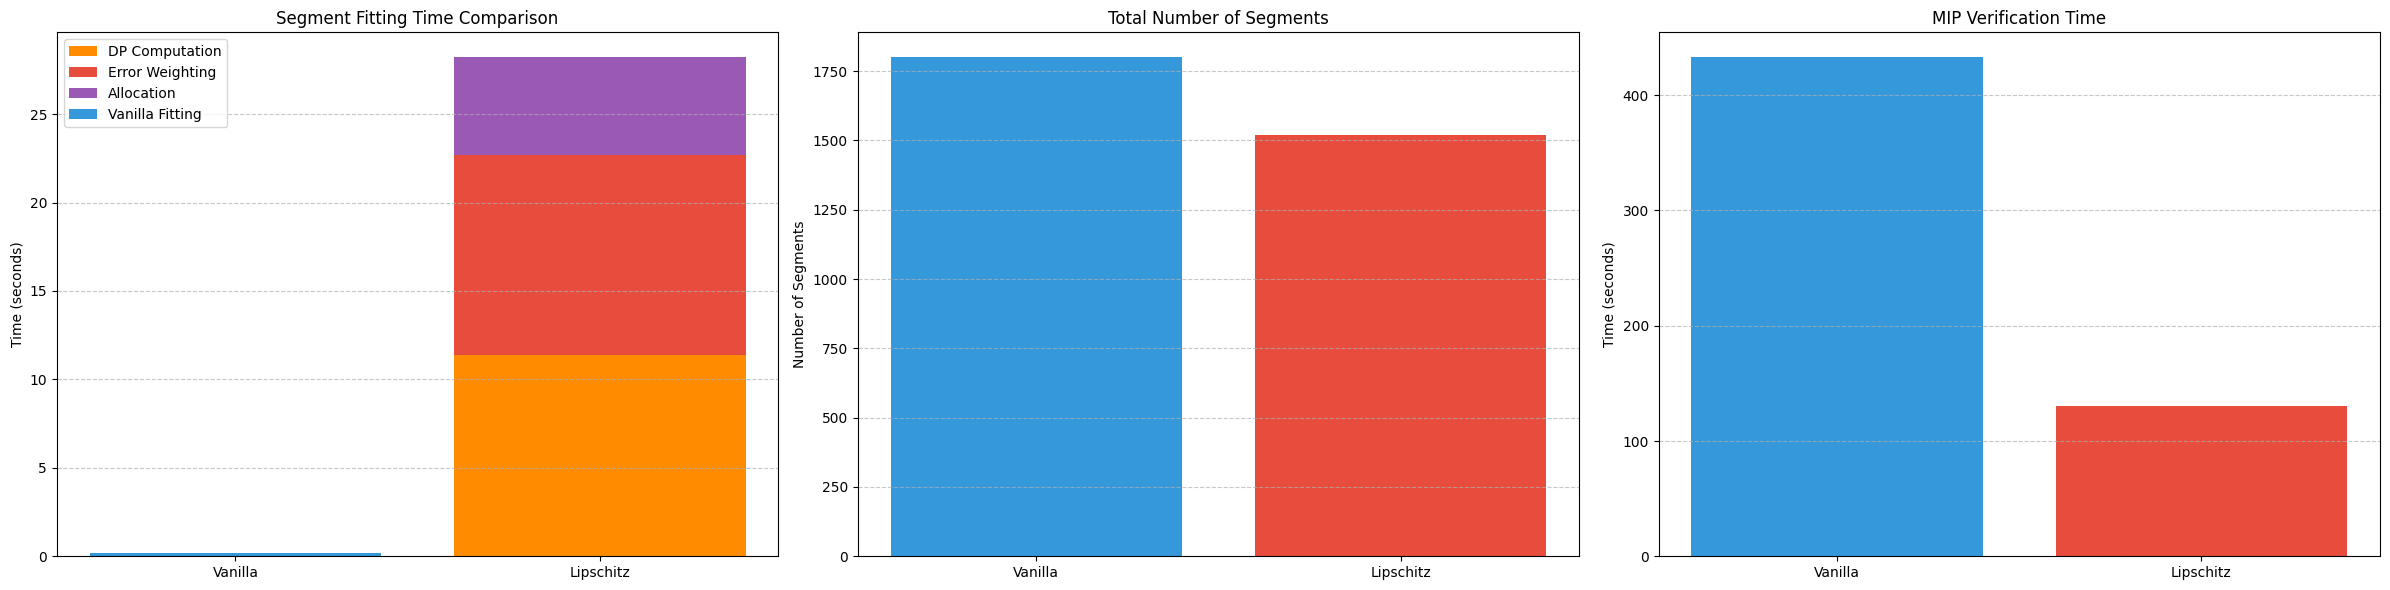

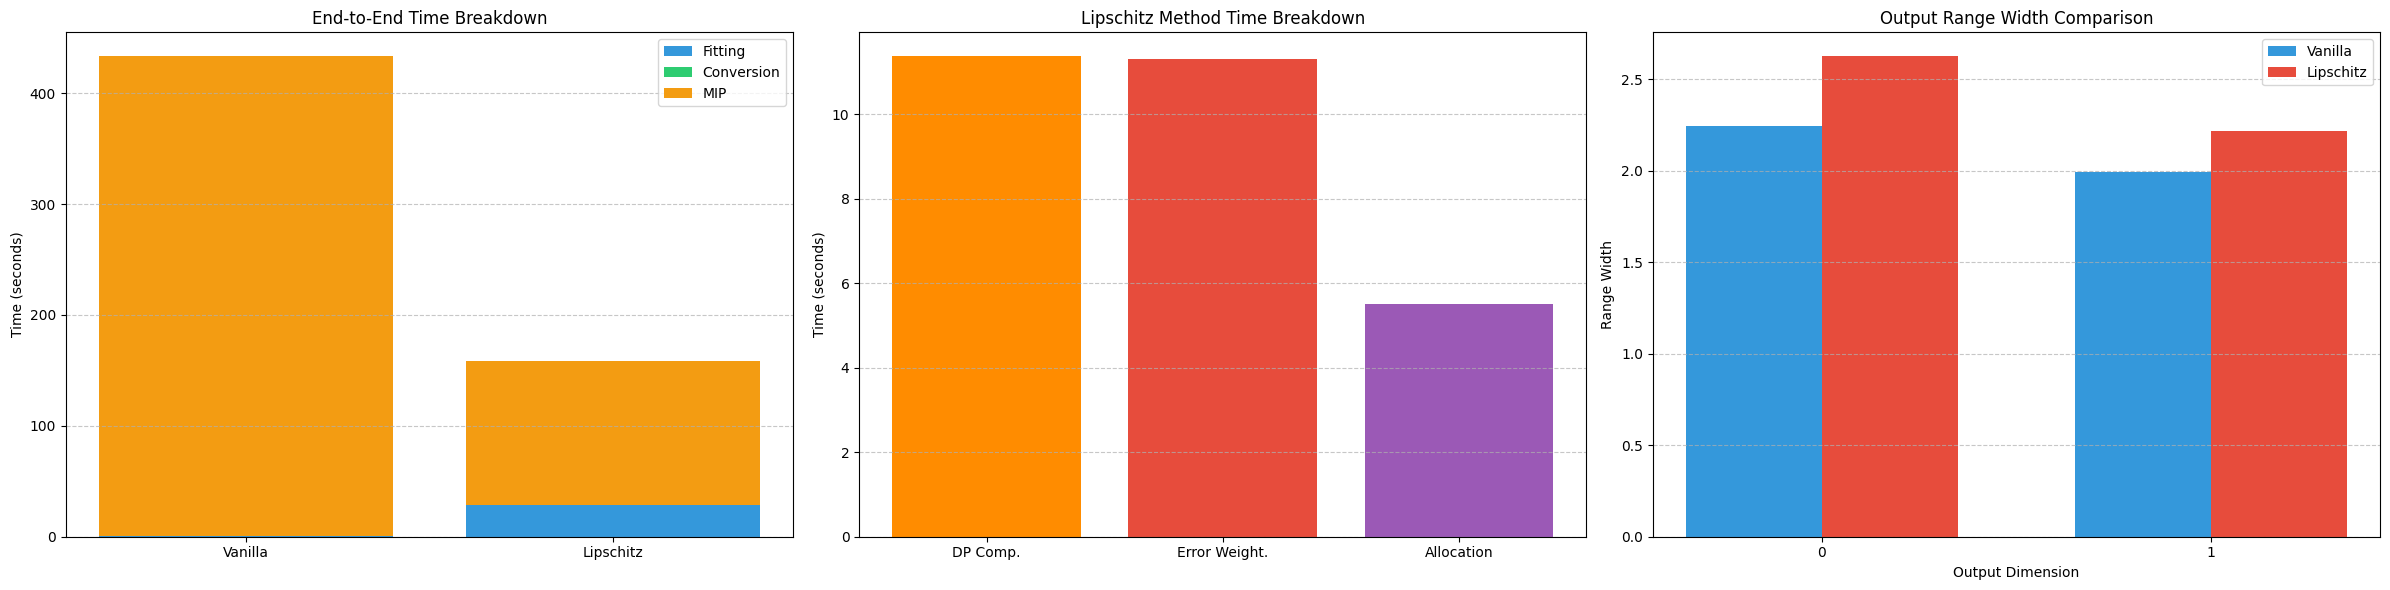

Results saved to output/4_15_2_neg0p45_0p45_20250423_222853
  - Console output: output/4_15_2_neg0p45_0p45_20250423_222853/output.md
  - Comparison chart: output/4_15_2_neg0p45_0p45_20250423_222853/output.png
  - Detailed metrics: output/4_15_2_neg0p45_0p45_20250423_222853/detailed_metrics.png


In [7]:
import os
import sys

def compute_propagated_error(kan_model, all_segments):
    """
    Compute the overall error for the vanilla fitting method.
    This is used to set the target for the DP fitting.
    """
    segment_dict = {}
    for segment_data in all_segments:
        layer_idx = segment_data['layer_idx']
        input_idx = segment_data['input_idx']
        output_idx = segment_data['output_idx']
        spline_key = (layer_idx, input_idx, output_idx)
        segment_dict[spline_key] = segment_data
    
    # Calculate Lipschitz constants for each B-spline, then compute propagated error
    lipschitz_constants = {}
    for layer_idx, layer in enumerate(kan_model.layers):
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                lip_const = calculate_bspline_lipschitz_constant(layer=layer, input_idx=input_idx,output_idx=output_idx)
                lipschitz_constants[spline_key] = lip_const
    spline_errors = {}
    for layer_idx, layer in enumerate(kan_model.layers):
        for input_idx in range(layer.input_dim):
            for output_idx in range(layer.output_dim):
                spline_key = (layer_idx, input_idx, output_idx)
                if spline_key not in segment_dict:
                    continue
                local_error = segment_dict[spline_key]['max_error']
                downstream_splines = get_all_downstream_splines(kan_model, layer_idx, output_idx)
                # Compute the product of Lipschitz constants of all downstream splines
                lipschitz_product = 1.0
                for ds_spline in downstream_splines:
                    if ds_spline in lipschitz_constants:
                        lipschitz_product *= lipschitz_constants[ds_spline]
                propagated_error = local_error * lipschitz_product
                spline_errors[spline_key] = propagated_error
    # Compute overall propagated error (max across all splines)
    if spline_errors:
        total_propagated_error = max(spline_errors.values())
    else:
        total_propagated_error = float('inf')
    
    return total_propagated_error, spline_errors, lipschitz_constants

def check_bounds(
    mip_min: Optional[float],
    mip_max: Optional[float],
    sampled_min: float,
    sampled_max: float,
    abs_tol: float = 1e-4,
    rel_tol: float = 1e-3
) -> Tuple[bool, bool, str]:
    message = []
    lower_bound_ok = False
    upper_bound_ok = False

    if mip_min is None:
        message.append("MIP Min bound is None.")
    else:
        # Check if MIP lower bound is less than or equal to sampled lower bound (allowing tolerance)
        # Tolerance = abs_tol + rel_tol * |sampled_min|
        lower_tol = abs_tol + rel_tol * abs(sampled_min)
        if mip_min <= sampled_min + lower_tol:
            lower_bound_ok = True
        else:
            message.append(f"Lower bound failed: MIP_min ({mip_min:.6f}) > Sampled_min ({sampled_min:.6f}) + Tol ({lower_tol:.6f})")

    if mip_max is None:
        message.append("MIP Max bound is None.")
    else:
        # Check if MIP upper bound is greater than or equal to sampled upper bound (allowing tolerance)
        # Tolerance = abs_tol + rel_tol * |sampled_max|
        upper_tol = abs_tol + rel_tol * abs(sampled_max)
        if mip_max >= sampled_max - upper_tol:
            upper_bound_ok = True
        else:
            message.append(f"Upper bound failed: MIP_max ({mip_max:.6f}) < Sampled_max ({sampled_max:.6f}) - Tol ({upper_tol:.6f})")

    return lower_bound_ok, upper_bound_ok, ". ".join(message)


def compare_kan_fitting_methods(
    kan_model, 
    input_dim: int,
    hidden_dim: int, 
    output_dim: int,
    input_bounds: List[Tuple[float, float]],
    max_error_threshold: float = 0.1,
    vanilla_segments_per_curve: int = 5,
    max_segments_lipschitz: int = 15,
    min_x: float = -5.0,
    max_x: float = 5.0,
    mip_time_limit_seconds: int = 6000,  # Default time limit for MIP solver
    num_validation_samples: int = 5000,  # Number of samples for bound validation
    abs_tol: float = 1e-3,  # Absolute tolerance for bound validation
    rel_tol: float = 1e-2,  # Relative tolerance for bound validation
    seed: int = 42          # Random seed for reproducibility
) -> Dict[str, Any]:
    """
    Run the vanilla fitting method and the Lipschitz-weighted fitting method
    and save the results.
    """
    used_backup_allocation = False
    print("=" * 80)
    print("KAN SEGMENT FITTING SETTINGS")
    print("=" * 80)
    print(f"Input Dimensions: {input_dim}")
    print(f"Hidden Dimensions: {hidden_dim}")
    print(f"Output Dimensions: {output_dim}")
    print(f"Input Bounds: {input_bounds}")
    print(f"Max Error Threshold: {max_error_threshold}")
    print(f"Vanilla Segments Per Curve: {vanilla_segments_per_curve}")
    print(f"Max Segments Lipschitz: {max_segments_lipschitz}")
    print(f"Min X: {min_x}")
    print(f"Max X: {max_x}")
    print(f"Time Limit (seconds): {mip_time_limit_seconds}")
    print(f"Number of Validation Samples: {num_validation_samples}")
    print(f"Absolute Tolerance: {abs_tol}")
    print(f"Relative Tolerance: {rel_tol}")
    print(f"Random Seed: {seed}")
    print("=" * 80)
    print("COMPARING KAN SEGMENT FITTING METHODS")
    print("=" * 80)
    
    results = {
        "vanilla": {},
        "lipschitz": {},
        "verification": {},
        "validation": {}
    }
    x_min_vec = [bound[0] for bound in input_bounds]
    x_max_vec = [bound[1] for bound in input_bounds]

    # ------ Vanilla Fitting ------
    print("\n" + "-" * 50)
    print("METHOD 1: VANILLA FITTING (EQUAL SEGMENTS)")
    print("-" * 50)
    vanilla_start = time.time()
    vanilla_segments = fit_kan_vanilla(kan_model, segments_per_curve=vanilla_segments_per_curve, min_x=min_x, max_x=max_x)
    vanilla_fit_time = time.time() - vanilla_start
    total_vanilla_segments = sum(len(segment_data['segments']) for segment_data in vanilla_segments)
    max_vanilla_error = max(segment_data['max_error'] for segment_data in vanilla_segments if np.isfinite(segment_data['max_error']))
    inf_error_count_vanilla = sum(1 for segment_data in vanilla_segments if not np.isfinite(segment_data['max_error']))
    results["vanilla"]["fit_time"] = vanilla_fit_time
    results["vanilla"]["total_segments"] = total_vanilla_segments
    results["vanilla"]["max_error"] = max_vanilla_error
    results["vanilla"]["inf_error_count"] = inf_error_count_vanilla
    results["vanilla"]["segments_data"] = vanilla_segments
    print(f"Vanilla Fitting Time: {vanilla_fit_time:.4f} seconds")
    print(f"Total Segments: {total_vanilla_segments}")
    print(f"Max Error: {max_vanilla_error:.6f}")
    print(f"Connections with Infinite Error: {inf_error_count_vanilla}")
    
    # ------ Lipschitz Fitting ------
    print("\n" + "-" * 50)
    print("METHOD 2: LIPSCHITZ-WEIGHTED FITTING")
    print("-" * 50)
    total_propagated_error, _, _ = compute_propagated_error(kan_model, vanilla_segments)
    max_error_threshold = total_propagated_error / 2 # Compute lipschitz error threshold based on vanilla error
    print("Max Error Threshold Changed to: ", total_propagated_error / 2)
    lipschitz_dp_start = time.time()
    error_tables, segments_tables, _ = compute_dp_tables_lipschitz(kan_model, min_x, max_x, max_segments_lipschitz)
    lipschitz_dp_time = time.time() - lipschitz_dp_start
    weighting_start = time.time()
    weighted_error_tables, _, _ = weight_dp_tables_lipschitz(kan_model, min_x, max_x, max_segments_lipschitz)
    weighting_time = time.time() - weighting_start
    allocation_start = time.time()
    optimal_allocation, actual_segments, total_lipschitz_segments, achieved_error, _, used_backup_allocation = fit_kan_optimally_lipschitz(
        weighted_error_tables, 
        segments_tables,
        max_error_threshold,
        max_segments=max_segments_lipschitz
    )
    allocation_time = time.time() - allocation_start
    lipschitz_segments = [] # Convert optimal allocation to same format as vanilla method for consistency
    for (layer_idx, input_idx, output_idx), num_segments in optimal_allocation.items():
        segments = actual_segments.get((layer_idx, input_idx, output_idx), [])
        max_error = error_tables.get((layer_idx, input_idx, output_idx), {}).get(num_segments, np.inf)
        lipschitz_segments.append({'layer_idx': layer_idx,'input_idx': input_idx,'output_idx': output_idx,'segments': segments,'max_error': max_error})
    lipschitz_fit_time = lipschitz_dp_time + weighting_time + allocation_time
    inf_error_count_lipschitz = sum(1 for segment_data in lipschitz_segments if not np.isfinite(segment_data['max_error']))
    results["lipschitz"]["dp_time"] = lipschitz_dp_time
    results["lipschitz"]["weighting_time"] = weighting_time
    results["lipschitz"]["allocation_time"] = allocation_time
    results["lipschitz"]["total_fit_time"] = lipschitz_fit_time
    results["lipschitz"]["total_segments"] = total_lipschitz_segments
    results["lipschitz"]["achieved_error"] = achieved_error
    results["lipschitz"]["inf_error_count"] = inf_error_count_lipschitz
    results["lipschitz"]["segments_data"] = lipschitz_segments
    print(f"Lipschitz DP Computation Time: {lipschitz_dp_time:.4f} seconds")
    print(f"Weighting Time: {weighting_time:.4f} seconds")
    print(f"Allocation Time: {allocation_time:.4f} seconds")
    print(f"Total Lipschitz Fitting Time: {lipschitz_fit_time:.4f} seconds")
    print(f"Total Segments: {total_lipschitz_segments}")
    print(f"Achieved Error: {achieved_error:.6f}")
    print(f"Connections with Infinite Error: {inf_error_count_lipschitz}")
    
    #  ------ Verification Comparison ------
    print("\n" + "-" * 50)
    print("VERIFICATION COMPARISON")
    print("-" * 50)

    # Vanilla
    print("\nRunning MIP verification for vanilla segments...")
    vanilla_start_verify = time.time()
    layer0_vanilla, layer1_vanilla = prep_segments_data(vanilla_segments, input_dim, hidden_dim, output_dim)
    vanilla_verify_start = time.time()
    vanilla_results = MIP_interval_analysis(layer0_vanilla, layer1_vanilla, x_min_vec, x_max_vec, M=1e4)
    vanilla_verify_time = time.time() - vanilla_verify_start
    total_vanilla_time = time.time() - vanilla_start_verify
    results["verification"]["vanilla_conversion_time"] = vanilla_verify_start - vanilla_start_verify
    results["verification"]["vanilla_mip_time"] = vanilla_verify_time
    results["verification"]["vanilla_total_time"] = total_vanilla_time
    results["verification"]["vanilla_results"] = vanilla_results
    print(f"Vanilla Verification Time: {vanilla_verify_time:.4f} seconds")
    print(f"Vanilla Total Time (conversion + verification): {total_vanilla_time:.4f} seconds")

    # Lipschitz
    print("\nRunning MIP verification for Lipschitz segments...")
    lipschitz_start_verify = time.time()
    layer0_lipschitz, layer1_lipschitz = prep_segments_data(lipschitz_segments, input_dim, hidden_dim, output_dim)
    lipschitz_verify_start = time.time()
    lipschitz_results = MIP_interval_analysis(layer0_lipschitz, layer1_lipschitz, x_min_vec, x_max_vec, M=1e4)
    lipschitz_verify_time = time.time() - lipschitz_verify_start
    total_lipschitz_time = time.time() - lipschitz_start_verify
    results["verification"]["lipschitz_conversion_time"] = lipschitz_verify_start - lipschitz_start_verify
    results["verification"]["lipschitz_mip_time"] = lipschitz_verify_time
    results["verification"]["lipschitz_total_time"] = total_lipschitz_time
    results["verification"]["lipschitz_results"] = lipschitz_results
    print(f"Lipschitz Verification Time: {lipschitz_verify_time:.4f} seconds")
    print(f"Lipschitz Total Time (conversion + verification): {total_lipschitz_time:.4f} seconds")
    if used_backup_allocation:
        print("\n!!!!!!!!!!!!!!!!!!!!!!!!!!!!!WARNING: LIPSCHITZ error too small, used best possible error!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
    else:
        print("\nLIPSCHITZ error was valid")
        
    return results


input_dim=kan_duffing.layers[0].input_dim
hidden_dim=kan_duffing.layers[-1].input_dim
output_dim=kan_duffing.layers[-1].output_dim
input_bounds = [(-0.45, 0.45)]  * kan_duffing.layers[0].input_dim 
model_size = f"{input_dim}_{hidden_dim}_{output_dim}"
input_range = f"{input_bounds[0][0]}_{input_bounds[0][1]}"
input_range = input_range.replace('-', 'neg')
input_range = input_range.replace('.', 'p')
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir = os.path.join("output", f"{model_size}_{input_range}_{timestamp}")
os.makedirs(output_dir, exist_ok=True)
original_stdout = sys.stdout
output_md_path = os.path.join(output_dir, "output.md")

class Tee:
    """
    Tee class to redirect stdout to multiple files.
    """
    def __init__(self, *files):
        self.files = files
    def write(self, obj):
        for f in self.files:
            f.write(obj)
            f.flush()
    def flush(self):
        for f in self.files:
            f.flush()
            
with open(output_md_path, 'w') as f:
    sys.stdout = Tee(original_stdout, f)
    results = compare_kan_fitting_methods(
        kan_model=kan_duffing,
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        output_dim=output_dim,
        input_bounds=input_bounds,
        max_error_threshold=1.0,
        vanilla_segments_per_curve=20,
        max_segments_lipschitz=60,
        min_x=-5.0,
        max_x=5.0,
        mip_time_limit_seconds=35000,
    )
sys.stdout = original_stdout
kan_verification_grapher.visualize_comparison_results(results, output_dir)
kan_verification_grapher.detailed_metrics_visualization(results, output_dir)
print(f"Results saved to {output_dir}")
print(f"  - Console output: {output_md_path}")
print(f"  - Comparison chart: {os.path.join(output_dir, 'output.png')}")
print(f"  - Detailed metrics: {os.path.join(output_dir, 'detailed_metrics.png')}")